# El Ciclo de Entrenamiento y Diagnóstico: Leyendo los Signos Vitales de la Red

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/05_ciclo_entrenamiento_y_diagnostico.ipynb)

## Objetivos


- Dominar la "Trinidad" de los datos en Deep Learning: **Train, Validation y Test**, y entender por qué se realiza esta separación sin caer en un dogma.
- Comprender la mecánica del tiempo en el entrenamiento: la relación matemática y física entre **Epochs, Batches y Steps**.
- Analizar el *Trade-off* del `batch_size`: Consumo de VRAM vs. Ruido en el gradiente vs. Velocidad de convergencia.
- Aprender a diagnosticar la salud de una red neuronal leyendo sus curvas de pérdida (*Loss*), identificando visualmente tasas de aprendizaje erróneas y el punto exacto de sobreajuste.
- Consolidar el aprendizaje con un "Checklist de Diagnóstico Rápido" para el día a día del ingeniero.

## Prerrequisitos


- Entendimiento de Optimizadores (Adam, SGD) y Regularización.
- Haber completado: [Optimizadores y Regularización](04_optimizadores_y_regularizacion.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

# Reproducibilidad estricta
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow versión: {tf.__version__}")

# Verificación de Hardware
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento será más lento.")

TensorFlow versión: 2.20.0
ADVERTENCIA: No se detectó GPU. El entrenamiento será más lento.


## 1. La Trinidad de los Datos



En Machine Learning clásico, a veces nos conformamos con dividir los datos en Entrenamiento y Prueba (Train/Test). En Deep Learning, debido a la inmensa cantidad de hiperparámetros (capas, neuronas, learning rate, optimizador, dropout), necesitamos una estructura más rigurosa de tres pilares:

1. **Train Set (Set de Entrenamiento):** Los datos que la red "ve" y utiliza para calcular gradientes y actualizar sus pesos.
2. **Validation Set (Set de Validación):** Datos que la red **NO usa para actualizar pesos**, pero sobre los cuales se evalúa *al final de cada época*.
3. **Test Set (Set de Prueba):** El cofre del tesoro. Se guarda bajo llave y **solo se usa una vez**, al final de todo el proyecto, para reportar el rendimiento real del modelo.

**Analogía del Estudiante (*re contra* quemada pero es la simple):**
- **Train:** Hacer los ejercicios de tarea en casa con el libro abierto.
- **Validation:** Hacer exámenes de práctica (*Mock Exams*). Si se reprueba el examen de práctica, ajustamos el método de estudio (cambiamos los hiperparámetros) y volvemos a intentarlo.
- **Test:** El examen final de la universidad. Si reprobamos, no podemos volver a estudiar y repetirlo inmediatamente; ya tenemos la nota final.

> **⚠️ PELIGRO DE *DATA SNOOPING*:** Si se ajusta la arquitectura de la red (ej. añadir una capa) basados en cómo rinde en el *Test Set*, estamos filtrando información del Test al modelo. La red se está sobreajustando indirectamente a los datos de prueba. En producción, el modelo colapsará. **Usar siempre el Validation Set para tomar decisiones de diseño.**

## 2. La Mecánica del Tiempo: Epochs, Batches y Steps



¿Por qué no le pasamos todo el dataset a la red de una sola vez?
Porque si tenemos 1 millón de imágenes de alta resolución, no existe una tarjeta gráfica (GPU) en el mundo con suficiente memoria RAM de video (VRAM) para cargarlas todas simultáneamente.

Por lo tanto, dividimos los datos en "lotes" (*Batches*). Esto define la mecánica del entrenamiento:

- **Batch Size (Tamaño del Lote):** Cantidad de muestras procesadas simultáneamente antes de actualizar los pesos. (Ej. 32 imágenes).
- **Step / Iteration (Paso):** Un *Forward Pass* + un *Backward Pass* (actualización de pesos) para un solo lote.
- **Epoch (Época):** Un recorrido completo por *todo* el dataset de entrenamiento.

**La Ecuación Fundamental:**  

$$ \text{Steps por Epoch} = \frac{\text{Total de Muestras}}{\text{Batch Size}} $$

Si tenemos 60.000 imágenes y un `batch_size` de 60:  
Necesitamos **1.000 steps** para completar **1 epoch**. La red actualizará sus pesos 1.000 veces por época.

## 3. Experimento 1: El *Trade-off* del Batch Size


El tamaño del lote no es solo un límite de memoria; es un hiperparámetro crucial que afecta la matemática de la convergencia.

- **Batch Pequeño (ej. 16):** El gradiente es muy ruidoso (se calcula sobre pocas muestras). La red da muchos pasos erráticos (depende del dataset, el que usamos es "muy ideal"), pero este "ruido" a veces le ayuda a escapar de mínimos locales. Tarda más tiempo real por época debido al cuello de botella de transferir datos constantemente a la GPU.
- **Batch Grande (ej. 1024):** El gradiente es muy preciso y suave. La GPU procesa matrices gigantescas de forma ultra-eficiente (épocas muy rápidas). Sin embargo, da muy pocos pasos por época, por lo que puede requerir más épocas totales para converger, y tiende a quedarse atascado en mínimos locales afilados (peor generalización).

Entonces, el tamaño del lote no es solo un límite de memoria; es un hiperparámetro crucial que afecta la matemática de la convergencia y el tiempo de cómputo.

Vamos a demostrar esto empíricamente entrenando la misma red con tres tamaños de lote: 16, 128 y 1024.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Iniciando experimento de Batch Sizes (5 épocas cada uno)...
Entrenando con Batch Size = 16...
Entrenando con Batch Size = 128...
Entrenando con Batch Size = 1024...
Experimento finalizado.


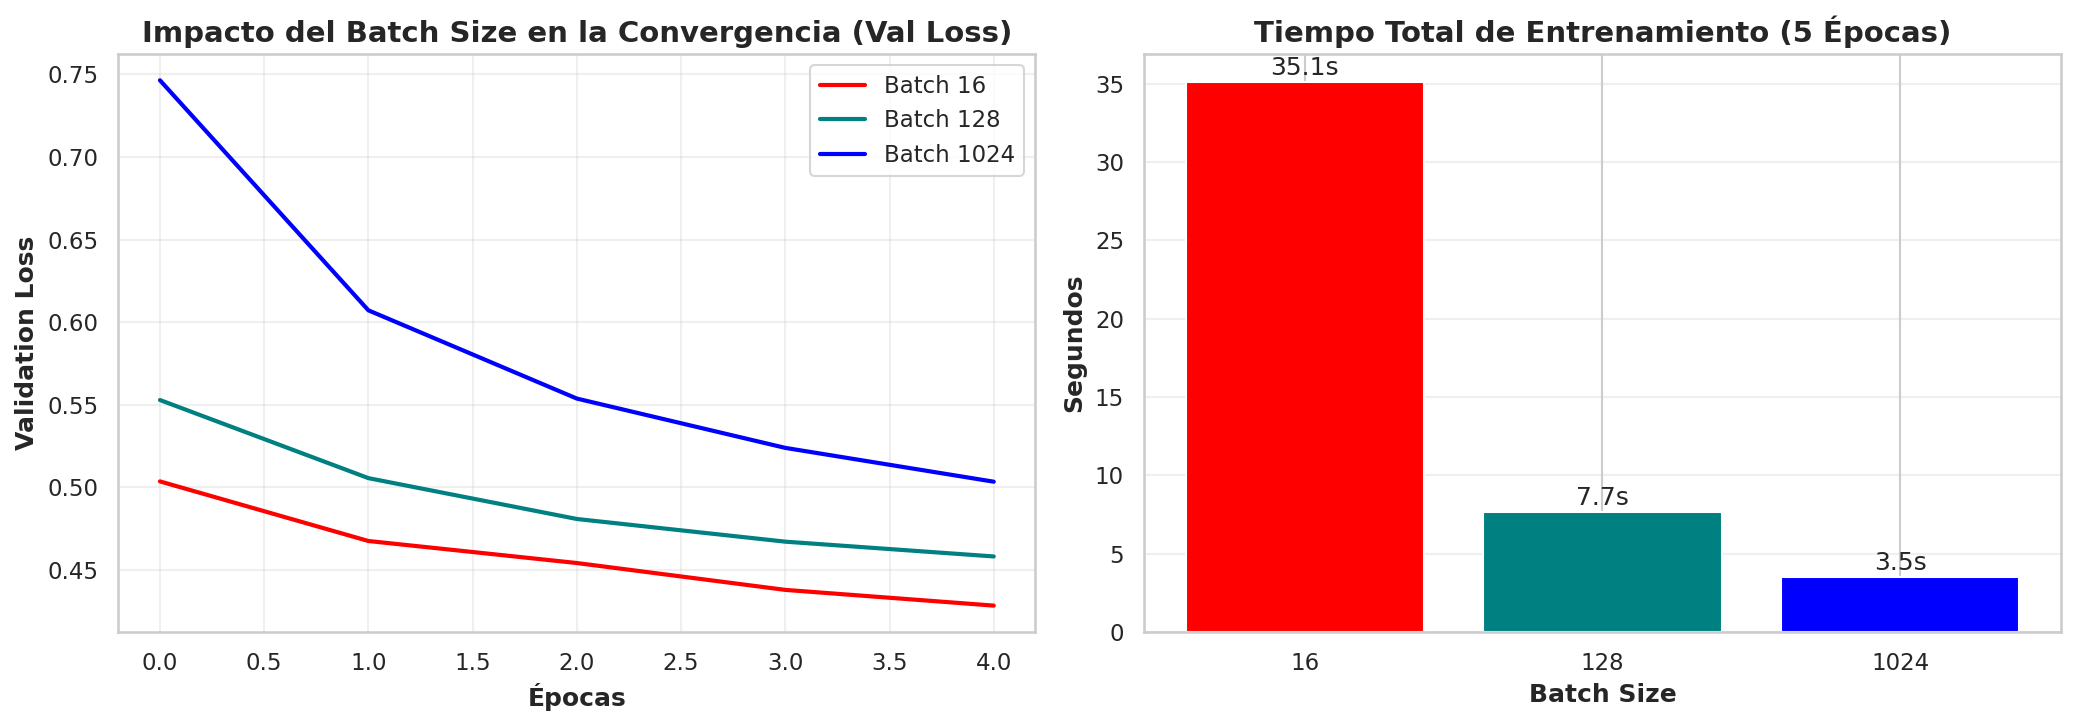

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import fashion_mnist

# 1. Carga de datos
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Función constructora
def construir_modelo():
    modelo = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        Dense(10, activation='softmax')
    ])
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

# 3. Experimento con diferentes Batch Sizes
batch_sizes = [16, 128, 1024]
historias_batch = {}
tiempos_batch = {}

print("Iniciando experimento de Batch Sizes (5 épocas cada uno)...")
for bs in batch_sizes:
    print(f"Entrenando con Batch Size = {bs}...")
    modelo = construir_modelo()

    inicio = time.time()
    # Usamos un subconjunto para que el experimento sea rápido
    hist = modelo.fit(X_train[:20000], y_train[:20000], epochs=5, validation_data=(X_test, y_test), batch_size=bs, verbose=0)
    fin = time.time()

    historias_batch[bs] = hist.history
    tiempos_batch[bs] = fin - inicio

print("Experimento finalizado.")

# 4. Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (Ruido vs Suavidad)
colores = {16: 'red', 128: 'teal', 1024: 'blue'}
for bs in batch_sizes:
    axes[0].plot(historias_batch[bs]['val_loss'], label=f'Batch {bs}', color=colores[bs], linewidth=2)

axes[0].set_title("Impacto del Batch Size en la Convergencia (Val Loss)", fontsize=14)
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de Tiempos
barras = axes[1].bar([str(bs) for bs in batch_sizes],[tiempos_batch[bs] for bs in batch_sizes], color=['red', 'teal', 'blue'])
axes[1].set_title("Tiempo Total de Entrenamiento (5 Épocas)", fontsize=14)
axes[1].set_xlabel("Batch Size")
axes[1].set_ylabel("Segundos")
axes[1].grid(axis='y', alpha=0.3)

# Añadir etiquetas de tiempo en las barras
for barra in barras:
    yval = barra.get_height()
    axes[1].text(barra.get_x() + barra.get_width()/2, yval + 0.1, f'{yval:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Análisis del *Trade-off*



Observar la hermosa tensión entre las matemáticas y el hardware en estas gráficas:

1. **La Curva de Pérdida (Izquierda - Matemática):** El `Batch 16` (rojo) logra la mejor convergencia por época (la línea llega más abajo). Al actualizar los pesos tan frecuentemente, la red aprende rapidísimo en términos de épocas. El `Batch 1024` (azul) es el peor matemáticamente: al promediar 1024 imágenes antes de dar un solo paso, da muy pocos pasos por época y aprende lento.
2. **El Tiempo de Cómputo (Derecha - Hardware):** Aquí se invierten los roles. El `Batch 16` tarda una eternidad (`~35,0 s`). ¿Por qué? Porque la GPU pasa más tiempo esperando a que la CPU le envíe miles de paquetitos minúsculos de datos que haciendo cálculos reales (cuello de botella de I/O). El `Batch 1024` satura los núcleos de la GPU, logrando la máxima eficiencia de hardware (`~3,5 s`).

**Criterio de Ingeniería:** El `Batch 128` (verde) es el "punto dulce". Tarda apenas `7,7 s` (casi tan rápido como el 1024) pero logra una convergencia casi idéntica al Batch 16.

> Entonces, por este lado viene la recomendación de comenzar los proyectos con `batch_size = 32`, `64` o `128`.

**Criterio de Ingeniería (Estándar de la Industria):**
Empezar siempre con `batch_size = 32`, `64` o `128`. Si el modelo es grande (ej. imágenes 4K) y la VRAM es limitada (Error OOM - *Out of Memory*, error al intentar entrenar), reducir a 16 u 8 (acá entra en juego el hardware disponble). Si se está entrenando en múltiples GPUs distribuidas, podemos escalar a `512` o `1024`, pero aparecen otras técnicas avanzadas de "calentamiento" (*Warmup*) del Learning Rate para no perder capacidad de generalización.

## 4. Experimento 2: Diagnóstico a través de las Curvas (El Learning Rate)



El hiperparámetro más crítico de toda red neuronal es la **Tasa de Aprendizaje (Learning Rate - LR)**. Dicta qué tan grandes son los pasos que da el optimizador.
- Si es **muy alto**, el optimizador saltará erráticamente por el paisaje de pérdida, rebotando en las paredes del valle y posiblemente divergiendo (Loss = NaN).
- Si es **muy bajo**, el optimizador dará pasos microscópicos. La red tardará semanas en entrenar o se quedará atascada en el primer bache que encuentre.

Vamos a simular estos escenarios clínicos para aprender a diagnosticarlos visualmente.



Iniciando diagnóstico de Learning Rates (10 épocas)...
Entrenando con LR: Muy Alto (0.1)...
Entrenando con LR: Óptimo (0.001)...
Entrenando con LR: Muy Bajo (1e-6)...
Diagnóstico finalizado.


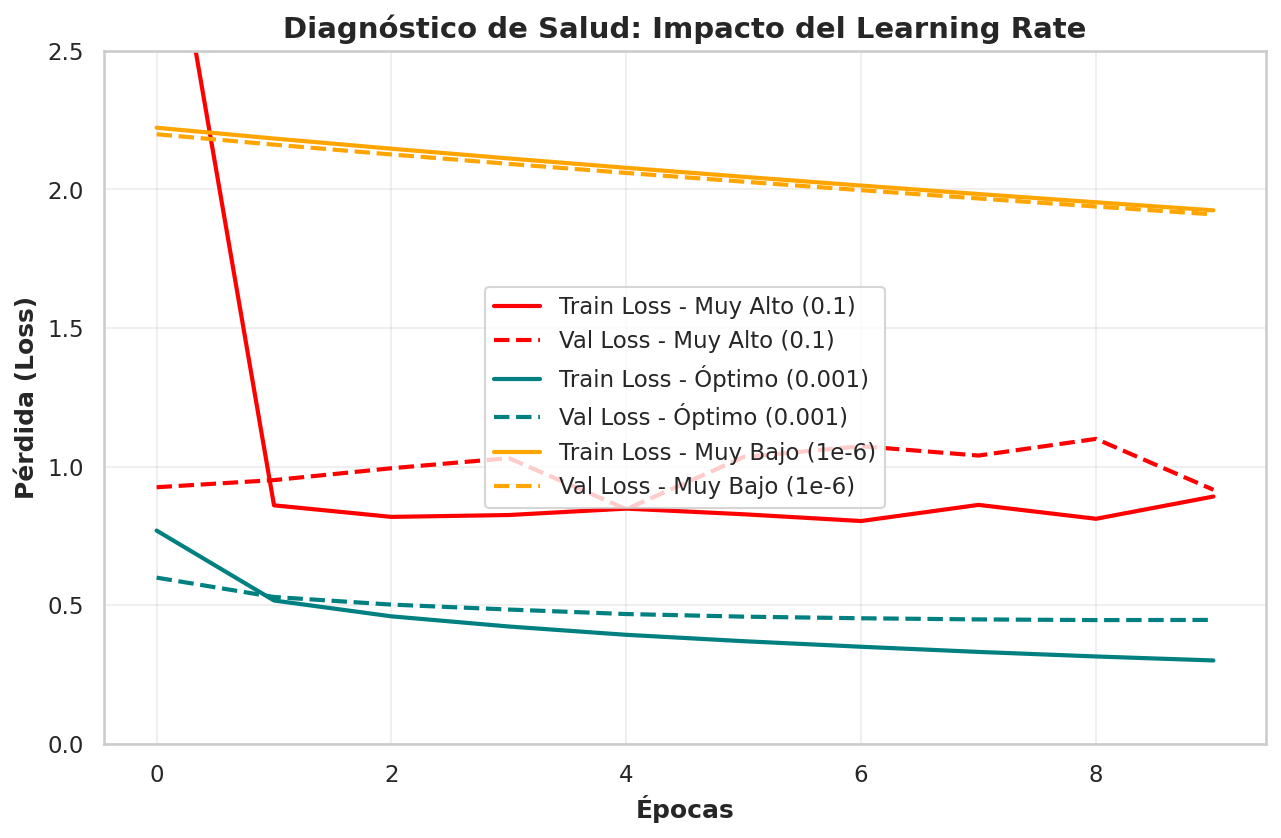

In [3]:
from tensorflow.keras.optimizers import Adam

# 1. Definimos los escenarios clínicos
learning_rates = {
    'Muy Alto (0.1)': 0.1,
    'Óptimo (0.001)': 0.001,
    'Muy Bajo (1e-6)': 1e-6
}

historias_lr = {}

print("Iniciando diagnóstico de Learning Rates (10 épocas)...")
for nombre, lr in learning_rates.items():
    print(f"Entrenando con LR: {nombre}...")
    modelo = construir_modelo()
    # Usamos Adam, pero forzamos el LR
    modelo.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = modelo.fit(X_train[:10000], y_train[:10000], epochs=10, validation_data=(X_test, y_test), batch_size=64, verbose=0)
    historias_lr[nombre] = hist.history

print("Diagnóstico finalizado.")

# 2. Visualización
plt.figure(figsize=(10, 6))
colores_lr = {'Muy Alto (0.1)': 'red', 'Óptimo (0.001)': 'teal', 'Muy Bajo (1e-6)': 'orange'}

for nombre in learning_rates.keys():
    plt.plot(historias_lr[nombre]['loss'], label=f'Train Loss - {nombre}', color=colores_lr[nombre], linewidth=2)
    plt.plot(historias_lr[nombre]['val_loss'], label=f'Val Loss - {nombre}', color=colores_lr[nombre], linestyle='--', linewidth=2)

plt.title("Diagnóstico de Salud: Impacto del Learning Rate", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.ylim(0, 2.5) # Limitamos el eje Y para ver los detalles
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### El Manual de Diagnóstico del Ingeniero


Al observar las curvas de entrenamiento de un modelo nuevo, debemos buscar estos patrones exactos:

1. **Descenso Lineal y Agónico (Naranja - LR Muy Bajo):** Observar cómo las líneas naranja bajan formando una línea recta casi perfecta. Las curvas de Train y Val están pegadas. La red está aprendiendo, pero tardará bastante. **Solución:** Aumentar el LR en un factor de 10 (ej. de `1e-5` a `1e-4`).
2. **Rebote Caótico (Roja - LR Muy Alto):** La pérdida arranca altísima, cae de golpe y luego se queda rebotando. La red está saltando de un lado a otro del valle sin poder llegar al fondo. A veces, el *Loss* se vuelve `NaN` (Not a Number). **Solución:** Reducir el LR drásticamente.
3. **Decaimiento Exponencial (Verde - LR Óptimo):** La pérdida cae rápidamente en las primeras épocas y luego comienza a aplanarse suavemente formando una "L" invertida. Este es el comportamiento sano que buscamos.


> 💡 **PRO-TIP DE LA INDUSTRIA: *Learning Rate Finder***  
> En lugar de adivinar el LR óptimo haciendo múltiples entrenamientos, la industria utiliza una técnica llamada **LR Finder** (popularizada por fast.ai). Consiste en entrenar la red por *una sola época*, comenzando con un LR minúsculo y aumentándolo exponencialmente en cada *batch*. Luego se grafica el *Loss* vs *Learning Rate*. El LR óptimo se encuentra justo en el punto donde la curva de pérdida tiene la pendiente descendente más pronunciada (antes de que empiece a rebotar).

### Identificando el Punto de *Overfitting*


> **Ejercicio**:  
Modificar el rango de la escala de la curva de arriba, además de las épocas (permitir bastantes más). Iniciar con el modelo de la curva verde (Óptima), observar atentamente la relación entre la línea sólida (Train) y la punteada (Validation).
Llegará un punto donde la línea sólida sigue bajando, pero la línea punteada se aplana o **comienza a subir**.
Ese punto de inflexión exacto es donde la red dejó de aprender patrones generales y comenzó a memorizar el ruido del set de entrenamiento. **Ese es el punto donde debimos haber detenido el entrenamiento.**

¿Se ve igual para el mismo modelo pero con otros LR? ¿Habría forma de automatizar el "encontrar" este punto para no sobre entrenar la red?

## 5. Checklist de Diagnóstico Rápido

Para evitar que este conocimiento se pierda en la teoría, adjunto un *cheat-sheet* para tener a mano a la hira de mirar las gráficas de sus modelos:

| Síntoma Visual (Curvas) | Diagnóstico Probable | Acción Correctiva Recomendada |
| :--- | :--- | :--- |
| **Train Loss y Val Loss bajan muy lento (línea recta).** | Learning Rate muy bajo. | Multiplicar LR por 10. |
| **Train Loss rebota violentamente o da `NaN`.** | Learning Rate muy alto o datos sin normalizar. | Dividir LR por 10. Verificar que los datos estén en rango `[0, 1]` o estandarizados. |
| **Train Loss baja a casi 0, pero Val Loss sube.** | **Overfitting** (Sobreajuste masivo). | Añadir Dropout, Regularización L2, o usar *Early Stopping*. |
| **Train Loss y Val Loss se estancan altos desde la época 1.** | Mala inicialización o arquitectura insuficiente (*Underfitting*). | Usar inicialización `he_normal`, añadir Batch Norm, o hacer la red más profunda/ancha. |
| **Error `OOM` (Out of Memory) al iniciar.** | Batch Size demasiado grande para la VRAM de la GPU. | Reducir Batch Size a la mitad (ej. de 64 a 32) hasta que corra. |
| **GPU al 10% de uso, CPU al 100%.** | Cuello de botella de I/O (Datos). | Aumentar Batch Size. Usar `tf.data.Dataset` con `.prefetch()`. |


## Anexo Práctico: Implementando un *Learning Rate Finder*

Adivinar el Learning Rate a ciegas es una pérdida de tiempo y recursos computacionales. Como mencionamos en el *Pro-Tip*, la industria utiliza el **LR Finder**.

En Keras, podemos implementar esto creando un pequeño **Callback** (una función que se ejecuta automáticamente durante el entrenamiento). Este script aumentará el LR exponencialmente después de cada *batch* y registrará la pérdida.

> ***Nota**: Profundizamos en el poder de los Callbacks en el notebook [Callbacks y KerasTuner](07_callbacks_y_kerastuner.ipynb), pero usamos este como un adelanto.*

Ejecutando LR Finder (1 Época)...
Búsqueda finalizada.


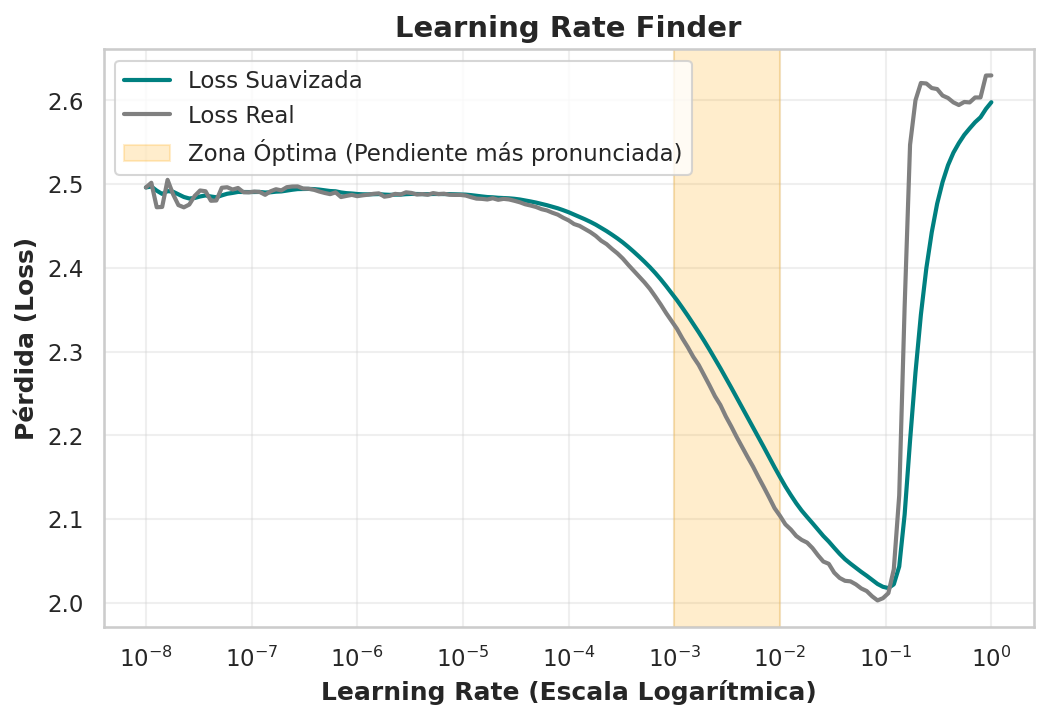

In [10]:
# Función auxiliar para suavizado
def smooth_curve(points, weight=0.8):
    smoothed_points = []
    for i in range(len(points)):
        if i == 0:
            smoothed_points.append(points[i])
        else:
            smoothed_points.append(smoothed_points[-1] * weight + points[i] * (1 - weight))
    return smoothed_points

# 1. Definimos el Callback personalizado
class LRFinder(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-5, max_lr=1e-1, steps_per_epoch=None):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = steps_per_epoch
        self.iteration = 0
        self.history = {'lr': [], 'loss':[]}

    def on_train_batch_begin(self, batch, logs=None):
        # Aumentamos el LR exponencialmente en cada batch
        fraction = self.iteration / self.total_steps
        lr = self.min_lr * (self.max_lr / self.min_lr) ** fraction
        self.model.optimizer.learning_rate = lr

    def on_train_batch_end(self, batch, logs=None):
        # Guardamos el LR actual y la pérdida resultante
        self.history['lr'].append(self.model.optimizer.learning_rate.numpy() if hasattr(self.model.optimizer.learning_rate, 'numpy') else self.model.optimizer.learning_rate)
        self.history['loss'].append(logs['loss'])
        self.iteration += 1

# 2. Preparamos el experimento (1 sola época es suficiente)
batch_size = 64
X_subset = X_train[:10000]
y_subset = y_train[:10000]
steps = len(X_subset) // batch_size

# Rango amplio para ver la curva, experimentar...
lr_finder = LRFinder(min_lr=1e-8, max_lr=1, steps_per_epoch=steps)

# 3. Entrenamos
print("Ejecutando LR Finder (1 Época)...")
modelo_finder = construir_modelo()
# Compilamos con un LR inicial cualquiera, el Callback lo sobrescribirá
modelo_finder.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy')
modelo_finder.fit(X_subset, y_subset, epochs=1, batch_size=batch_size, callbacks=[lr_finder], verbose=0)
print("Búsqueda finalizada.")

# 4. Visualización del LR Finder
plt.figure(figsize=(8, 5))
# Suavizamos un poco la curva de pérdida para ver mejor la tendencia
loss_suavizado = smooth_curve(lr_finder.history['loss'], weight=0.8)

plt.plot(lr_finder.history['lr'], loss_suavizado, color='teal', linewidth=2, label='Loss Suavizada')
plt.plot(lr_finder.history['lr'], lr_finder.history['loss'], color='gray', linewidth=2, label='Loss Real')
plt.xscale('log') # Eje X en escala logarítmica es VITAL
plt.title("Learning Rate Finder", fontsize=14)
plt.xlabel("Learning Rate (Escala Logarítmica)")
plt.ylabel("Pérdida (Loss)")
plt.grid(True, alpha=0.3)

# Marcamos la zona ideal
plt.axvspan(1e-3, 1e-2, color='orange', alpha=0.2, label='Zona Óptima (Pendiente más pronunciada)')
plt.legend()
plt.show()

### ¿Cómo leer esta gráfica? (El Criterio del Ingeniero)



La curva del LR Finder tiene tres fases inconfundibles que revelan la física del optimizador:

1. **La Zona Plana (Izquierda, $10^{-8}$ a $10^{-5}$):** El *Learning Rate* es tan bajo que los pasos del optimizador son microscópicos. La red no está aprendiendo nada; la pérdida se mantiene constante.
2. **La Caída y la Zona Óptima (Centro, franja naranja):** A medida que el LR crece, la red empieza a aprender y la pérdida cae. **El LR óptimo NO es el punto más bajo de la gráfica.** El LR óptimo se encuentra un poco antes, en la zona donde la pendiente hacia abajo es **más pronunciada** (en nuestro caso, entre $10^{-3}$ y $10^{-2}$). Aquí es donde la red aprende más rápido sin volverse inestable.
3. **El Rebote y la Explosión (Derecha, $> 10^{-1}$):** El LR se vuelve demasiado alto. El optimizador da pasos tan grandes que "salta" por encima del valle de pérdida, los gradientes explotan y la curva se dispara verticalmente.

**Conclusión Práctica:** Con esta simple prueba de unos pocos segundos, sabemos que configurar nuestro optimizador Adam con un `learning_rate = 1e-3` o `2e-3` nos dará el entrenamiento más rápido y estable posible, eliminando por completo la necesidad de adivinar. *De nada!*

## Conexiones y Próximos Pasos


Aprendimos las nociones para leer los signos vitales de nuestra red y a entender la mecánica del tiempo y la memoria durante el entrenamiento. Sin embargo, hasta ahora solamente construimos modelos muy simples, apilando capas una detrás de otra como si fueran bloques de Lego en línea recta.

¿Qué pasa si queremos construir una red que reciba dos tipos de datos diferentes (ej. una imagen y un texto) al mismo tiempo? ¿O una red que tenga múltiples salidas?

- ➡️ **Siguiente:** En el notebook [El Ecosistema Keras y APIs](06_ecosistema_keras_y_apis.ipynb), abandonamos la limitante `Sequential API` y dominamos la **Functional API**, la herramienta que nos permite construir grafos acíclicos complejos y arquitecturas de nivel de producción.
- 🔄 **Relacionado:** Más adelante, en el notebook [Callbacks y KerasTuner](07_callbacks_y_kerastuner.ipynb), aprendemos a automatizar la detección del punto de *Overfitting* para que la red detenga su entrenamiento por sí sola usando `EarlyStopping`.

## Referencias


### Artículos Fundacionales

1. **Smith, L. N. (2018)**. *A disciplined approach to neural network hyper-parameters: Part 1 — Learning rate, batch size, momentum, and weight decay*. arXiv preprint.  
   [[arXiv]](https://arxiv.org/abs/1803.09820)  
   (Lectura **obligatoria** para entender la relación entre Learning Rate y Batch Size).

2. **Goyal, P., Dollár, P., Girshick, R., Noordhuis, P., Wesolowski, L., Kyrola, A., ... & He, K. (2017)**. *Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour*. arXiv preprint.  
   [[arXiv]](https://arxiv.org/abs/1706.02677)  
   (Paper clave de Facebook AI que popularizó el uso de batches muy grandes).

3. **Bengio, Y. (2012)**. *Practical Recommendations for Gradient-Based Training of Deep Architectures*. In Neural Networks: Tricks of the Trade.  
   (Excelente guía práctica de Yoshua Bengio).

### Recursos Adicionales

- **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. *Deep Learning* (Capítulo 8 y 11). MIT Press. Disponible gratis en [deeplearningbook.org](https://www.deeplearningbook.org/).
- **Smith, L. N. (2017)**. *Cyclical Learning Rates for Training Neural Networks*. arXiv. (Introducción al Learning Rate Finder).
- Documentación oficial de Keras:  
  [Callbacks](https://keras.io/api/callbacks/)  
  [Model.fit()](https://keras.io/api/models/model_training_apis/)

---


## Entorno de Ejecución


In [8]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
